In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt     
from PostprocessingFunctions import write_vtk

In [3]:
%%bash
cd ..
g++ -std=c++17 -Wall Ramp.cpp SRC/Mesh.cpp SRC/Flux.cpp SRC/Simulation.cpp SRC/Solver.cpp SRC/Cell.cpp -o RampMMS 

        

SRC/Flux.cpp: In member function ‘std::pair<std::array<double, 4>, std::array<double, 4> > Flux::MusclExtrapolation(Cell*, char)’:
SRC/Flux.cpp:523:16: warning: unused variable ‘p1’ [-Wunused-variable]
  523 |         double p1; double p3;
      |                ^~
SRC/Flux.cpp:523:27: warning: unused variable ‘p3’ [-Wunused-variable]
  523 |         double p1; double p3;
      |                           ^~
SRC/Simulation.cpp: In member function ‘void Simulation::write_Cd(const string&)’:
SRC/Simulation.cpp:68:12: warning: unused variable ‘Cd’ [-Wunused-variable]
   68 |     double Cd = 0.0;
      |            ^~
SRC/Solver.cpp: In member function ‘void Solver::RK2_step()’:
SRC/Solver.cpp:55:16: warning: unused variable ‘is_mms’ [-Wunused-variable]
   55 |     const bool is_mms = inputs["is_mms"];
      |                ^~~~~~
SRC/Solver.cpp: In member function ‘void Solver::set_mms_bcs(Cell*)’:
SRC/Solver.cpp:260:12: warning: unused variable ‘gamma’ [-Wunused-variable]
  260 |     do

In [4]:
%%bash
cd ..
./RampMMS

Shape = (3328, 4)
setting pointersSetting ambient Conditions...Setting inflow Conditions...Freestream Pressure: 12270   Freestream Density: 0.197017 Freestream vel1169.63Iteration: 0
Upwind Order: 1;  Norms:
  Density   : 119.495  U-velocity: 139796  V-velocity: 21843  Pressure  : 1.09398e+08
Iteration: 1
Upwind Order: 1;  Norms:
  Density   : 104.336  U-velocity: 120709  V-velocity: 20895.1  Pressure  : 9.79141e+07
Iteration: 2
Upwind Order: 1;  Norms:
  Density   : 93.5413  U-velocity: 106868  V-velocity: 20689.5  Pressure  : 8.91789e+07
Iteration: 3
Upwind Order: 1;  Norms:
  Density   : 86.2548  U-velocity: 97334.4  V-velocity: 21056.1  Pressure  : 8.26301e+07
Iteration: 4
Upwind Order: 1;  Norms:
  Density   : 81.6708  U-velocity: 91195.9  V-velocity: 21799.6  Pressure  : 7.78196e+07
Iteration: 5
Upwind Order: 1;  Norms:
  Density   : 78.9447  U-velocity: 87430.7  V-velocity: 22785.6  Pressure  : 7.43101e+07
Iteration: 6
Upwind Order: 1;  Norms:
  Density   : 77.3309  U-velocity: 

In [13]:


data = np.loadtxt("../Ramp_primitives_FINE.csv", delimiter=",")
NI = 64//2
NJ = 208//2
print(data.shape)   # (4, Ncells)
rho = data[0, :].reshape((NI,NJ))
u   = data[1, :].reshape((NI,NJ))
v   = data[2, :].reshape((NI,NJ))
p   = data[3, :].reshape((NI,NJ))
#p1   = data[4, :].reshape((NI,NJ))


(5, 3328)


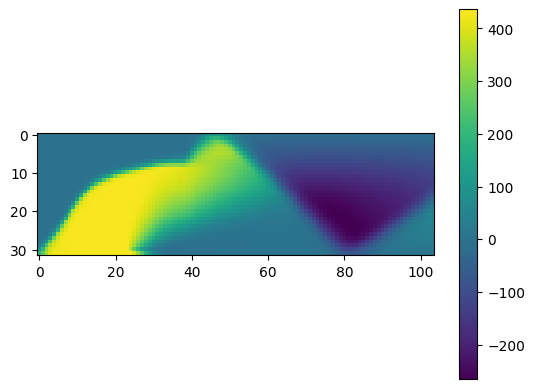

In [14]:
plt.imshow(v[::-1])
plt.colorbar()

In [15]:
plt.imshow((TP[::-1])[:,-90:])

NameError: name 'TP' is not defined

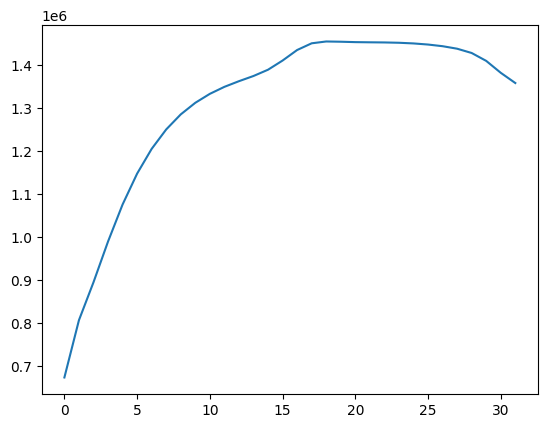

In [16]:
gamma = 1.4


V2 = u**2 + v**2
a2 = gamma * p / rho
M2 = V2 / a2

TP  = p * (1 + 0.5 * (gamma - 1) * M2) ** (gamma / (gamma - 1))
pressure_exit = (TP[::-1])[:,-1] + .5*((TP[::-1])[:,-1]-(TP[::-1])[:,-2])
p0_inf = 12270 * ((1 + 0.5 * (gamma - 1) * 4**2) ** (gamma / (gamma - 1)))
plt.plot(p0_inf-pressure_exit)


In [17]:
from PostprocessingFunctions import load_grid
x,y = load_grid(f"/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Ramp/Inlet.{105}x{33}.grd")

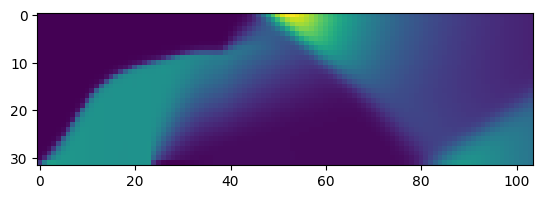

In [18]:
plt.imshow(p[::-1])

In [19]:
dy = np.abs(y[1,-1]-y[0,-1])
H = .4
avg_pressure_losses = (1/H)*(np.sum((p0_inf-pressure_exit)*dy))

In [20]:
avg_pressure_losses

1307771.0366751624

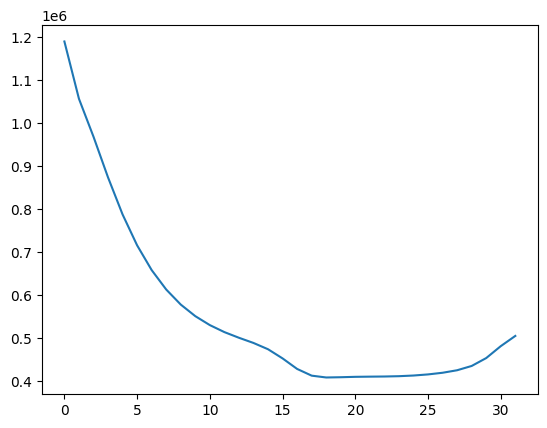

In [21]:
plt.plot(pressure_exit)

In [22]:
avg_pressure_losses
1320000/p0_inf

0.7085277299547742

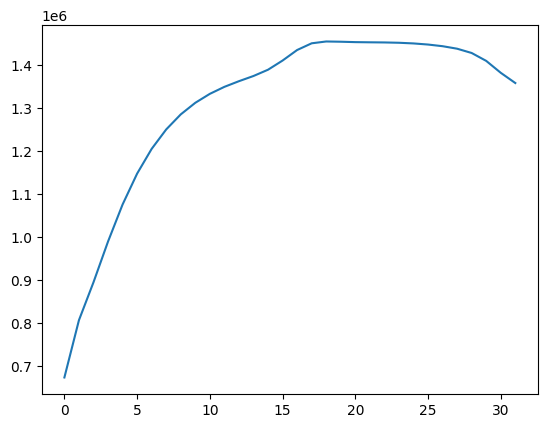

In [23]:
plt.plot()
plt.plot(np.ones_like(pressure_exit)*p0_inf - pressure_exit)

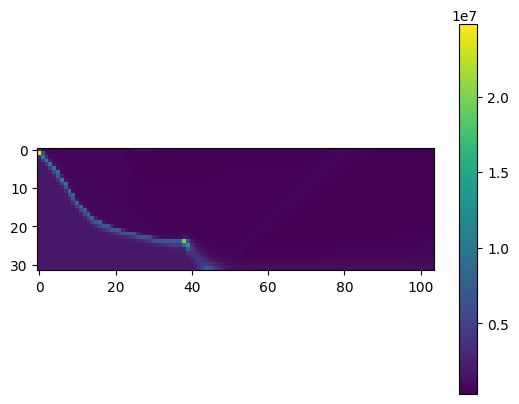

In [24]:
plt.imshow(TP)
plt.colorbar()

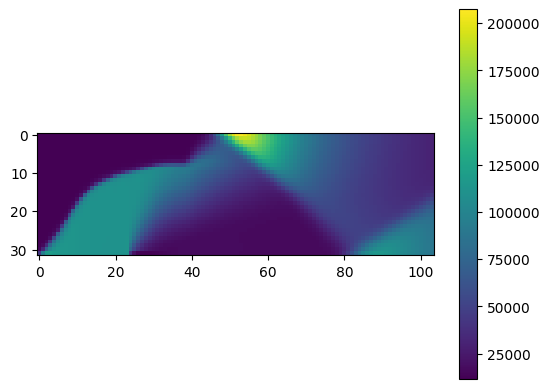

In [25]:
plt.imshow(p[::-1])
plt.colorbar()

In [26]:
# Van Leer
Coarse_Mesh_PL = 1351487.9392236304 #1346715.4718292253
Medium_Mesh_PL = 1335781.8006066524 #1334433.076320613
Fine_Mesh_PL = 1328288.0260057596


# Roes method
Coarse_Mesh_PL_Roe = 1307983.8252381878
Medium_Mesh_PL_Roe = 1307771.0366751156
Fine_Mesh_PL_Roe = 1310822.0975398095


In [27]:
np.min(p)

11599.397293414271

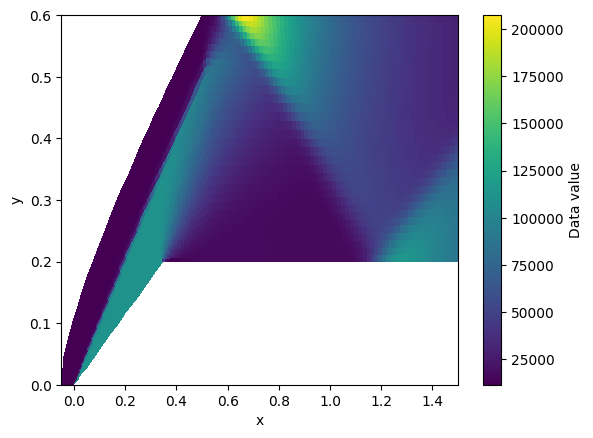

In [28]:
 

plt.pcolormesh(x, y, p, shading='auto', cmap='viridis')
plt.colorbar(label="Data value")
plt.xlabel("x")
plt.ylabel("y")
plt.show()



In [29]:
write_vtk("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Ramp/Inlet.105x33.grd",rho,u,v,p,output_name="../VTK/Fine_Ramp_residuals.vtk")

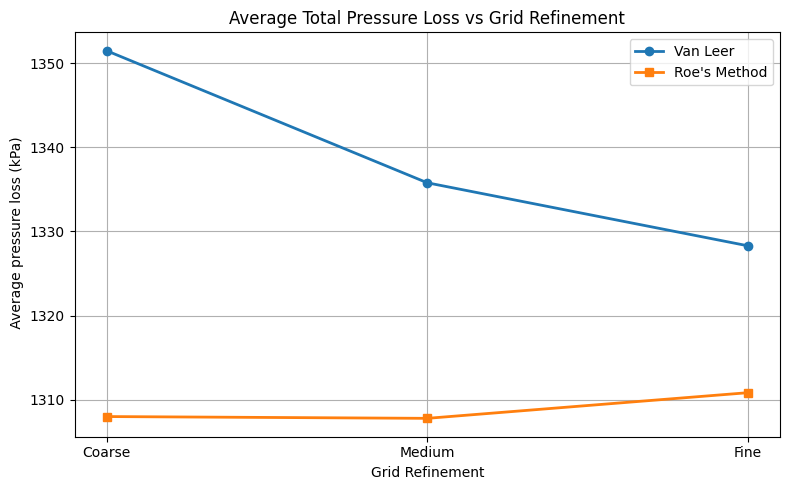

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Grid refinement labels (from coarse to fine)
labels = ["Coarse", "Medium", "Fine"]

# Pressure losses (lower is better)
van_leer = [
    1351487.9392236304/1000,  # Coarse
    1335781.8006066524/1000,  # Medium
    1328288.0260057596/1000   # Fine
]

roe = [
    1307983.8252381878/1000,  # Coarse
    1307771.0366751156/1000,  # Medium
    1310822.0975398095/1000   # Fine
]

# Convert to average loss relative to the coarse mesh for each method
van_leer_loss = np.array(van_leer) - van_leer[0]
roe_loss = np.array(roe) - roe[0]

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(labels))

ax.plot(x, van_leer, marker='o', label='Van Leer', linewidth=2)
ax.plot(x, roe, marker='s', label="Roe's Method", linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel(" Average pressure loss (kPa)")
ax.set_xlabel("Grid Refinement")
ax.set_title("Average Total Pressure Loss vs Grid Refinement")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


In [31]:
import numpy as np
from scipy.optimize import fsolve

def theta_beta_m_eq(beta_deg, M1, theta_deg, gamma=1.4):
    beta = np.radians(beta_deg)
    theta = np.radians(theta_deg)
    term1 = 2 * (1/np.tan(beta))
    term2 = (M1**2 * np.sin(beta)**2 - 1)
    term3 = M1**2 * (gamma + np.cos(2*beta)) + 2
    return np.tan(theta) - (term1 * term2 / term3)

# Solve for beta
M1 = 4
theta = 30
beta_initial_guess = 40  # weak shock

beta_solution = fsolve(theta_beta_m_eq, beta_initial_guess, args=(M1, theta))
print(f"Oblique shock angle β ≈ {beta_solution[0]:.2f}°")


Oblique shock angle β ≈ 45.22°
